# BLIP - Image Captioning

https://huggingface.co/docs/transformers/en/model_doc/blip

BLIP(Bootstrapping Language-Image Pre-training)은 이미지와 텍스트를 함께 다루는 Vision-Language Pre-training 모델이다.

BLIP은 image captioning, visual question answering, image-text retrieval 같은 여러 비전-언어 태스크에 활용될 수 있도록 설계되었다.

그 중 image captioning을 먼저 다룬다.

## CLIP과 BLIP Captioning의 차이

| 구분 | CLIP | BLIP Image Captioning |
|---|---|---|
| 입력 | 이미지 + 텍스트 후보들 | 이미지 |
| 출력 | 후보 텍스트별 유사도 점수 | 이미지 설명 문장 |
| 성격 | 이해/검색 중심 | 생성 중심 |

CLIP은 텍스트 후보를 직접 넣어야 한다. 후보에 정답이 없으면 가장 비슷한 후보를 고를 뿐이다.

BLIP captioning은 후보를 주지 않아도 이미지 내용을 보고 설명 문장을 생성한다. 

In [1]:
import torch
from PIL import Image
from pathlib import Path
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

from transformers import BlipProcessor, BlipForConditionalGeneration

## 예제 이미지 준비

앞의 CLIP 실습과 연결하기 위해 같은 COCO 예제 이미지를 사용한다.

이미지 크기: (640, 480)
이미지 타입: <class 'PIL.Image.Image'>


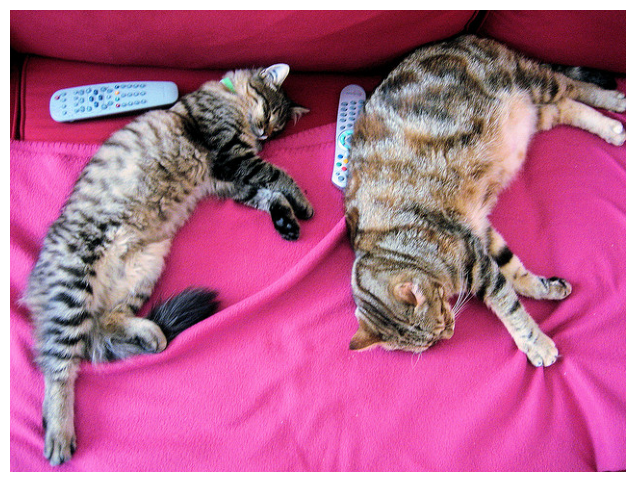

In [2]:
image_dir = Path('images')
image_dir.mkdir(exist_ok=True)

image_path = image_dir / 'coco_cats.jpg'
image_url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

if not image_path.exists():
    urlretrieve(image_url, image_path)

# Image.open()은 이미지 파일을 PIL 이미지 객체로 불러온다.
# convert('RGB')는 이미지를 RGB 3채널 형식으로 맞춘다.
image = Image.open(image_path).convert('RGB')

print('이미지 크기:', image.size)
print('이미지 타입:', type(image))

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## BLIP Processor와 Captioning 모델 로드
`Salesforce/blip-image-captioning-base` 모델 사용

https://huggingface.co/Salesforce/blip-image-captioning-base

In [3]:
model_id = 'Salesforce/blip-image-captioning-base'

processor = BlipProcessor.from_pretrained(model_id)
model = BlipForConditionalGeneration.from_pretrained(model_id)
model.eval()

print('모델 로드 완료 : ', model_id)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Playdata\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료 :  Salesforce/blip-image-captioning-base


## 이미지 전처리 확인

In [4]:
inputs = processor(images=image, return_tensors='pt')

for key, value in inputs.items():
    print(key, value.shape)

pixel_values torch.Size([1, 3, 384, 384])


## 이미지 캡션 생성

In [6]:
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        num_beams=3,
        max_new_tokens=30
    )

caption = processor.decode(output_ids[0], skip_special_tokens=True)

print('생성한 토큰 ID : ', output_ids[0])
print('생성한 캡션 : ', caption)

생성한 토큰 ID :  tensor([30522,  2048,  8870,  5777,  2006,  1037,  6411,   102])
생성한 캡션 :  two cats sleeping on a couch


## 생성 옵션 바꿔보기

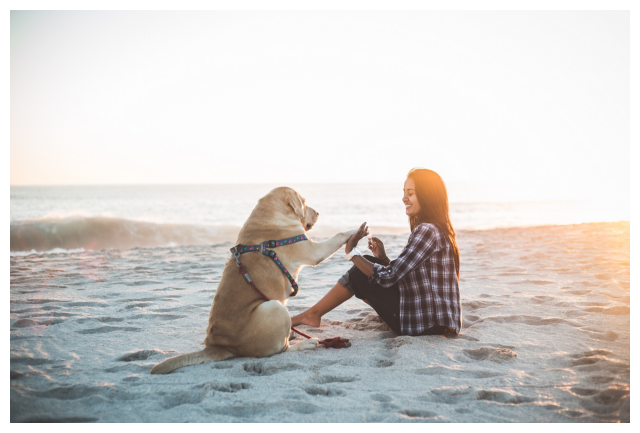

In [7]:
import requests

second_image_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'

second_image = Image.open(requests.get(second_image_url, stream=True).raw).convert('RGB')

plt.figure(figsize=(8, 6))
plt.imshow(second_image)
plt.axis('off')
plt.show()

In [8]:
# 두 번째 이미지 전처리
second_inputs = processor(
    images=second_image,
    return_tensors='pt'
)

In [9]:
sampling_options = [
    {'do_sample' : True, 'temperature': 0.7, 'top_p': 0.9},
    {'do_sample' : True, 'temperature': 1.0, 'top_p': 0.9},
    {'do_sample' : True, 'temperature': 1.2, 'top_p': 0.95},
]

for option in sampling_options:
    with torch.no_grad():
        output_ids = model.generate(**second_inputs, max_new_tokens=30, **option)
        caption = processor.decode(output_ids[0], skip_special_tokens=True)
        print(f'{option} : {caption}')

{'do_sample': True, 'temperature': 0.7, 'top_p': 0.9} : a woman is sitting on the beach with a dog
{'do_sample': True, 'temperature': 1.0, 'top_p': 0.9} : a woman sitting on a beach next to a yellow dog
{'do_sample': True, 'temperature': 1.2, 'top_p': 0.95} : this dog is looking through a hand
